In [1]:
import sys
from pathlib import Path
# add project root to path
project_root = Path.cwd().parent  # assuming you're running from Notebooks/
sys.path.append(str(project_root))

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from gan.models import Generator, Discriminator
from gan.training import train_wgan_gp

In [3]:


def make_gaussian_mixture(
    n_samples=50_000,
    centers=8,
    radius=5.0,
    std=0.5,
    seed=0
):
    """
    Create data set with disk like clusters in circle around the origin
    Parameters
    ----------
    n_samples : int
        number of data points to be generated
    centers : int
        number of clusters to be generated
    radius : float
        distance to origin of center of clusters
    std : float
        standard deviation of distance of points to cluster center
    seed : int
        random seed
    Returns
    -------
    np.ndarray
        array of generated sample points
    """
    rng = np.random.default_rng(seed)

    angles = np.linspace(0, 2*np.pi, centers, endpoint=False)
    means = np.stack([
        radius * np.cos(angles),
        radius * np.sin(angles)
    ], axis=1)

    samples = []
    for _ in range(n_samples):
        k = rng.integers(0, centers)
        x = rng.normal(loc=means[k], scale=std, size=2)
        samples.append(x)

    return np.array(samples, dtype=np.float32)

In [4]:
X = make_gaussian_mixture()

In [5]:
G = Generator(
    noise_dim=2,
    num_hidden_layers=2,
    out_dim=2,
    hidden_dims=(128,128),
    output_activation=nn.Tanh
)

D = Discriminator(
    feature_dim=2,
    num_hidden_layers=2,
    hidden_dims=(128,128)
)

In [6]:
# scale data to [-1,1] range
X_min , X_max = X.max(axis=0), X.min(axis=0)
X_scaled = 2 * (X-X_min) / (X_max - X_min) - 1
X_torch = torch.tensor(X_scaled)
# train on the data
train_wgan_gp(
    X=X_torch,
    G=G,
    D=D
)

Epoch 10/200 | D loss: -1.0441 | G loss: -0.4437
Epoch 20/200 | D loss: 0.1064 | G loss: 5.2606
Epoch 30/200 | D loss: -0.0187 | G loss: -0.8388
Epoch 40/200 | D loss: -0.0033 | G loss: -0.5620
Epoch 50/200 | D loss: 0.0500 | G loss: -0.5298
Epoch 60/200 | D loss: 0.0453 | G loss: -0.5921
Epoch 70/200 | D loss: 0.0240 | G loss: 1.4148
Epoch 80/200 | D loss: 0.0294 | G loss: 1.9211
Epoch 90/200 | D loss: 0.0312 | G loss: 2.2170
Epoch 100/200 | D loss: 0.0295 | G loss: 3.2983
Epoch 110/200 | D loss: 0.0264 | G loss: 3.4093
Epoch 120/200 | D loss: 0.0296 | G loss: 3.7087
Epoch 130/200 | D loss: 0.0287 | G loss: 4.5938
Epoch 140/200 | D loss: 0.0245 | G loss: 0.8616
Epoch 150/200 | D loss: 0.0260 | G loss: -0.9262
Epoch 160/200 | D loss: 0.0270 | G loss: -4.1569
Epoch 170/200 | D loss: 0.0289 | G loss: -10.2605
Epoch 180/200 | D loss: 0.0296 | G loss: -14.6485
Epoch 190/200 | D loss: 0.0292 | G loss: -13.5732
Epoch 200/200 | D loss: 0.0251 | G loss: -15.5404


In [7]:
@torch.no_grad()
def plot_samples(G, X_real, n=2000, title=None):
    """
    plot fake and real data
    Parameters
    ----------
    G: Generator
        used to generate fake points
    X_real : np.ndarray
        real data
    n : int
        number of points
    title : str | None
        optional title for plot
    """
    # generate fake data
    X_fake_raw = G.generate(n).cpu().numpy()
    # unscale the data
    X_fake = (X_fake_raw + 1) / 2 * (X_max - X_min) + X_min
    plt.figure(figsize=(5,5))
    plt.scatter(X_real[:n,0], X_real[:n,1], s=5, alpha=0.3, label="Real")
    plt.scatter(X_fake[:,0], X_fake[:,1], s=5, alpha=0.3, label="Fake")
    if title is not None:
        plt.title(title)
    plt.legend()
    plt.axis("equal")
    plt.show()

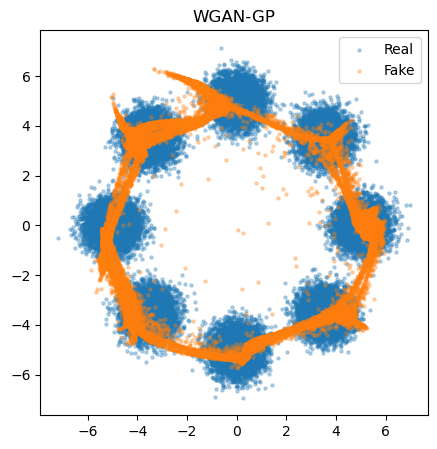

In [8]:
plot_samples(G, X, len(X), "WGAN-GP")